# Chess RL — Resumable Self-Play Training

Runs the **self-play → train** loop one iteration at a time, continuing from your
colleague's supervised-learning network (`sl_best.weights.h5`). Every *completed*
iteration saves a checkpoint, logs metrics, and writes the games' PGNs, so you can
interrupt the kernel at any moment and resume with no corruption.

**Usage**
1. Launch Jupyter from your repo root (`~/semester_6/chess_bot`).
2. Run sections **1–4** once per session (setup). Section 4 seeds `iter_0` from the SL net.
3. Run **section 5** whenever the laptop is idle. Press interrupt (■) to stop — the last
   completed iteration is always safe. Re-run sections 4+5 to resume.
4. Use **section 6** to inspect progress.

## 1. Configuration

In [5]:
import os

# ===== EDIT THESE =====
REPO_ROOT   = os.path.abspath(".")     # assumes Jupyter launched from repo root
WEIGHT_PATH = "reinforcement_learning/networks/weights/sl_best.weights.h5"  # SL starting net

# Network — MUST match the SL weights you start from
NUM_RES_BLOCKS = 20
NUM_FILTERS    = 256
SE_RATIO       = 8
LEARNING_RATE  = 0.0002   # lowered for RL fine-tuning (SL default was 0.001).
                          # Tune in 1e-4..3e-4 based on early-iteration losses.

# Self-play
GAMES_PER_ITER   = 10
NUM_SIMULATIONS  = 100    # lower (30-50) for faster but noisier iterations
MAX_MOVES        = 300
TEMP_THRESHOLD   = 30
SEARCH_BATCH_SIZE = 4     # leaves per network call. CPU: 1-4. Kaggle GPU: 16-32.

# Training
TRAIN_EPOCHS     = 1
TRAIN_BATCH_SIZE = 32

# Parallel self-play across CPU cores (serial is the safe default).
USE_PARALLEL = True
NUM_WORKERS  = 4

# Persistence
SAVE_DATA = True   # also pickle the raw positions for each iteration

# ===== Derived paths =====
RUN_DIR   = os.path.join(REPO_ROOT, "reinforcement_learning", "training_runs")
CKPT_DIR  = os.path.join(RUN_DIR, "checkpoints")
DATA_DIR  = os.path.join(RUN_DIR, "data")
GAMES_DIR = os.path.join(RUN_DIR, "games")
LOG_DIR   = os.path.join(RUN_DIR, "logs")
LOG_FILE  = os.path.join(LOG_DIR, "training.log")
ITER_CSV  = os.path.join(LOG_DIR, "iterations.csv")
LOOKUP_PATH = os.path.join(REPO_ROOT, "reinforcement_learning", "move_lookup.json")

for d in (CKPT_DIR, DATA_DIR, GAMES_DIR, LOG_DIR):
    os.makedirs(d, exist_ok=True)

print("Checkpoints:", CKPT_DIR)
print("Start net:  ", WEIGHT_PATH)

Checkpoints: /home/timle/semester_6/chess_bot/reinforcement_learning/training_runs/checkpoints
Start net:   reinforcement_learning/networks/weights/sl_best.weights.h5


## 2. Imports & logging

In [6]:
import sys
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import time
import glob
import csv
import json
import pickle
import logging
from datetime import datetime

import numpy as np

from reinforcement_learning.monte_carlo_tree_search.mcts_v2 import MCTS, SelfPlayGame
from reinforcement_learning.helpers.converter import Converter
from reinforcement_learning.networks.big_network import BigNetwork

# force=True resets handlers so re-running this cell doesn't duplicate log lines
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.FileHandler(LOG_FILE), logging.StreamHandler()],
    force=True,
)
log = logging.getLogger("train")


def log_iteration_csv(metrics: dict):
    """Append one iteration's metrics as a row in iterations.csv."""
    write_header = not os.path.exists(ITER_CSV)
    with open(ITER_CSV, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(metrics.keys()))
        if write_header:
            w.writeheader()
        w.writerow(metrics)

## 3. Helper functions

`run_one_iteration` does self-play → save games → train → checkpoint → return metrics.
The checkpoint is written last, which is what makes interrupting safe.

In [7]:
def latest_iteration():
    """Highest completed iteration number on disk, or None if no checkpoints."""
    ckpts = glob.glob(os.path.join(CKPT_DIR, "iter_*.weights.h5"))
    if not ckpts:
        return None
    nums = [int(os.path.basename(c)[len("iter_"):-len(".weights.h5")]) for c in ckpts]
    return max(nums)


def flatten_games(games):
    """list[list[sample]] (per game) -> flat list[sample] (per position)."""
    return [s for game in games for s in game]


def generate_games(network, mcts, prev_weight_path):
    """Return (flat list of position samples, list of per-game PGN records)."""
    if USE_PARALLEL:
        from reinforcement_learning.monte_carlo_tree_search.mcts_v2 import play_games_parallel
        games, records = play_games_parallel(
            n_games=GAMES_PER_ITER, weight_path=prev_weight_path, lookup_path=LOOKUP_PATH,
            num_simulations=NUM_SIMULATIONS, num_res_blocks=NUM_RES_BLOCKS,
            num_filters=NUM_FILTERS, num_workers=NUM_WORKERS,
            max_moves=MAX_MOVES, temperature_threshold=TEMP_THRESHOLD,
            resign_threshold=None, search_batch_size=SEARCH_BATCH_SIZE,
        )
    else:
        games, records = [], []
        for g in range(GAMES_PER_ITER):
            game = SelfPlayGame(
                mcts, temperature_threshold=TEMP_THRESHOLD,
                max_moves=MAX_MOVES, resign_threshold=None,
                search_batch_size=SEARCH_BATCH_SIZE,
            )
            games.append(game.play())
            records.append(game.record)
            log.info(f"  game {g + 1}/{GAMES_PER_ITER} done")
    return flatten_games(games), records


def save_games_json(iteration, records, prev_weight_path, num_positions, selfplay_seconds):
    payload = {
        "iteration": iteration,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "generated_with_weights": os.path.basename(prev_weight_path),  # net that played
        "config": {
            "games_per_iter": GAMES_PER_ITER,
            "num_simulations": NUM_SIMULATIONS,
            "search_batch_size": SEARCH_BATCH_SIZE,
            "max_moves": MAX_MOVES,
            "temperature_threshold": TEMP_THRESHOLD,
            "num_res_blocks": NUM_RES_BLOCKS,
            "num_filters": NUM_FILTERS,
        },
        "num_games": len(records),
        "num_positions": num_positions,
        "selfplay_seconds": round(selfplay_seconds, 1),
        "games": [{"game": i, **rec} for i, rec in enumerate(records)],
    }
    with open(os.path.join(GAMES_DIR, f"iter_{iteration}.json"), "w") as f:
        json.dump(payload, f, indent=2)


def run_one_iteration(iteration, network, mcts, converter, prev_weight_path):
    # 1. SELF-PLAY
    t0 = time.perf_counter()
    samples, records = generate_games(network, mcts, prev_weight_path)
    t_selfplay = time.perf_counter() - t0
    if not samples:
        raise RuntimeError("Self-play produced no positions — check max_moves / resign.")

    # Persist games immediately — self-play is the expensive part to lose
    save_games_json(iteration, records, prev_weight_path, len(samples), t_selfplay)

    if SAVE_DATA:
        with open(os.path.join(DATA_DIR, f"iter_{iteration}.pkl"), "wb") as f:
            pickle.dump(samples, f)

    # 2. TRAIN
    t1 = time.perf_counter()
    board_tensors  = np.array([s["board_tensor"]  for s in samples])
    policy_targets = np.array([s["policy_target"] for s in samples])
    value_targets  = np.array([[s["value_target"]] for s in samples], dtype=np.float32)
    history = network.train(
        board_tensors, policy_targets, value_targets,
        epochs=TRAIN_EPOCHS, batch_size=TRAIN_BATCH_SIZE, verbose=0,
    )
    t_train = time.perf_counter() - t1

    # 3. CHECKPOINT (written last -> interrupting before here loses nothing saved)
    weight_path = os.path.join(CKPT_DIR, f"iter_{iteration}.weights.h5")
    network.save(weight_path)

    h = history.history
    def last(key):
        v = h.get(key)
        return round(float(v[-1]), 4) if v else None

    return {
        "iteration": iteration,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "num_games": GAMES_PER_ITER,
        "num_positions": len(samples),
        "selfplay_seconds": round(t_selfplay, 1),
        "train_seconds": round(t_train, 1),
        "total_seconds": round(t_selfplay + t_train, 1),
        "loss": last("loss"),
        "policy_loss": last("policy_output_loss"),
        "value_loss": last("value_output_loss"),
        "weights_file": os.path.basename(weight_path),
    }


def run_iterations(num_iterations, network, mcts, converter):
    """Run up to num_iterations, resuming from the latest checkpoint.
    Interrupt the kernel any time; the last completed iteration is always saved."""
    start = latest_iteration()
    if start is None:
        raise RuntimeError("No checkpoint. Run section 4 first to seed iter_0.")

    session_t0 = time.perf_counter()
    completed = 0
    log.info(f"=== Session start: resuming after iter_{start}, planning {num_iterations} iters ===")
    try:
        for it in range(start + 1, start + 1 + num_iterations):
            log.info(f"--- Iteration {it} starting ---")
            prev_path = os.path.join(CKPT_DIR, f"iter_{it - 1}.weights.h5")
            m = run_one_iteration(it, network, mcts, converter, prev_path)
            log_iteration_csv(m)
            log.info(
                f"Iteration {it} DONE in {m['total_seconds']}s "
                f"(self-play {m['selfplay_seconds']}s, train {m['train_seconds']}s) | "
                f"loss={m['loss']} | {m['num_positions']} positions | saved {m['weights_file']}"
            )
            completed += 1
    except KeyboardInterrupt:
        log.warning(
            f"Interrupted. {completed} iteration(s) this session. "
            f"Last safe checkpoint: iter_{latest_iteration()}."
        )
        print("\n⏹  Stopped cleanly — safe to use your laptop. Re-run to resume.")
    finally:
        mins = (time.perf_counter() - session_t0) / 60
        log.info(f"=== Session end: {completed} iterations, {mins:.1f} min ===")

## 4. Build / resume the network (run once per session)

On a fresh run (no checkpoints) this **seeds `iter_0` from the SL weights** so iteration 1
continues from your colleague's network, not random init.

In [8]:
def setup_network():
    network = BigNetwork(
        num_res_blocks=NUM_RES_BLOCKS,
        num_filters=NUM_FILTERS,
        se_ratio=SE_RATIO,
        learning_rate=LEARNING_RATE,
        lookup_path=LOOKUP_PATH,
    )
    converter = Converter(lookup_path=LOOKUP_PATH)
    mcts = MCTS(network=network, converter=converter, num_simulations=NUM_SIMULATIONS)

    n = latest_iteration()
    if n is None:
        assert os.path.exists(WEIGHT_PATH), f"SL weights not found: {WEIGHT_PATH}"
        network.load(WEIGHT_PATH)                       # continue from the SL net
        path = os.path.join(CKPT_DIR, "iter_0.weights.h5")
        network.save(path)
        log.info(f"Seeded iter_0 from {os.path.basename(WEIGHT_PATH)} (colleague's SL net).")
    else:
        path = os.path.join(CKPT_DIR, f"iter_{n}.weights.h5")
        network.load(path)
        log.info(f"Resumed from {os.path.basename(path)}.")
    return network, converter, mcts


network, converter, mcts = setup_network()

20:33:38 | INFO | Resumed from iter_0.weights.h5.


## 5. Run training iterations

**Verify one iteration first** (`run_iterations(1, ...)`), confirm a checkpoint, a
`games/iter_1.json`, and a CSV row appear, then raise the count for real runs.

In [ ]:
run_iterations(3, network, mcts, converter)

20:33:41 | INFO | === Session start: resuming after iter_0, planning 1 iters ===
20:33:41 | INFO | --- Iteration 1 starting ---
I0000 00:00:1782412422.365670   26923 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782412422.365670   26920 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782412422.365666   26921 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782412422.365670

  Move 20: r1bq1rk1/1pp2ppp/n3pn2/p3b3/3P4/P3P3/1P1NBPPP/R1BQ1RK1 w - - 0 11
  Move 20: rn2k2r/pppbbp1p/3p4/4p1P1/QPP3n1/5N2/PB1PPP1P/RN2KB1R w KQkq - 2 11
  Move 20: r1b1kb1r/pp1nqp1p/2p1p1p1/8/2PP2B1/2N1B3/PP3PPP/R2QK2R w KQkq - 1 11
  Move 20: r2qkbnr/p2p1p1p/1pn3p1/8/2B1P3/4p1P1/PP5P/RNB1K1NR w KQkq - 0 11
  Move 40: r4rk1/1b3ppp/1p2p3/2p1q3/pB2n3/P3PPP1/1PQ1B2P/2RR2K1 w - - 0 21
  Move 40: r3kr2/pp1bb2p/2np4/3N2P1/1pPPN2P/1Q6/PB2Pp2/R3KBR1 w q - 0 21
  Move 40: r1bk4/pp2b3/2p2n1p/3p4/2PB2r1/3Q4/PP3PPP/R5K1 w - - 2 21
  Move 40: 2rqk3/p2p1n2/1p1b2pr/3Nn2p/3BPN1P/6P1/PP2K3/5R1R w - - 5 21
  Move 60: r3r1k1/1R4p1/1p2pp1n/2p4p/p6P/P1B3P1/1P2K3/3R4 w - - 2 31
  Move 60: 4r3/3b4/2pk3p/3r4/Q2b4/8/PP3PPP/2R3K1 w - - 5 31
  Move 60: 2k5/pp1b3p/3p2P1/3P2P1/2P1Q3/1P6/1B1KP3/r7 w - - 0 31
  Move 60: 6k1/p2p4/1p3Rp1/2b1nr2/1P1rPKpP/6P1/P7/8 w - - 1 31
  Move 80: 7Q/2k5/1bb4p/8/8/6PP/PP3r1K/3r4 w - - 0 41
  Game over after 80 moves: 0-1
  Move 80: 8/1k6/1p1p1Q2/1Q1P4/2P5/8/1B1KP3/8 w - - 3 41
 

20:54:39 | INFO | Iteration 1 DONE in 1358.1s (self-play 1306.4s, train 51.7s) | loss=3.0334 | 881 positions | saved iter_1.weights.h5
20:54:39 | INFO | === Session end: 1 iterations, 22.7 min ===


## 6. Inspect progress

,iteration,timestamp,num_games,num_positions,selfplay_seconds,train_seconds,total_seconds,loss,policy_loss,value_loss,weights_file
0,1,2026-06-25T20:54:39,10,881,1306.4,51.7,1358.1,3.0334,2.7071,0.3253,iter_1.weights.h5


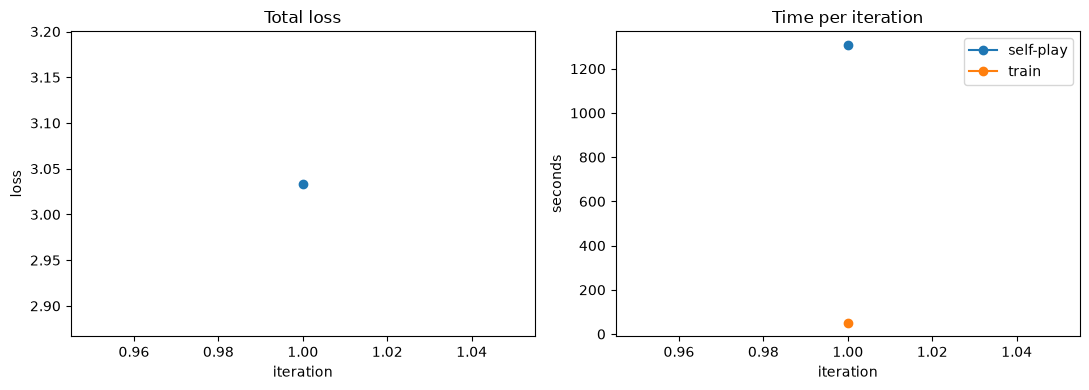

In [10]:
try:
    import pandas as pd
    df = pd.read_csv(ITER_CSV)
    display(df.tail(20))
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        ax[0].plot(df["iteration"], df["loss"], marker="o")
        ax[0].set(title="Total loss", xlabel="iteration", ylabel="loss")
        ax[1].plot(df["iteration"], df["selfplay_seconds"], marker="o", label="self-play")
        ax[1].plot(df["iteration"], df["train_seconds"], marker="o", label="train")
        ax[1].set(title="Time per iteration", xlabel="iteration", ylabel="seconds")
        ax[1].legend()
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("Plotting skipped:", e)
except FileNotFoundError:
    print("No iterations logged yet — run section 5 first.")